# Major Project: Seasonal Agriculture Performance Analysis

This notebook performs the complete project workflow:

1. Dataset understanding
2. Data cleaning and preparation
3. Seasonal performance comparison
4. Major seasonal pattern identification
5. Environmental relationship analysis
6. Resource-usage analysis
7. Economic analysis
8. Region and crop comparisons
9. Unusual-pattern and outlier analysis
10. Statistical testing
11. Evidence-based conclusions and recommendations


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

FILE = "/seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(FILE)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 1. Explore and Understand the Dataset

In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()


Rows: 4000
Columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop    

In [14]:
print("Season distribution:")
display(df["Season"].value_counts())

print("\nCrop distribution:")
display(df["Crop"].value_counts())

print("\nState distribution:")
display(df["State"].value_counts())

print("\nIrrigation methods:")
display(df["Irrigation_Method"].value_counts())


Season distribution:


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594



Crop distribution:


,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305



State distribution:


,count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484



Irrigation methods:


,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


## 2. Data Cleaning and Preparation

In [15]:
print("Duplicate rows:", df.duplicated().sum())

missing = df.isnull().sum()
print("\nMissing values:")
display(missing[missing > 0])


Duplicate rows: 0

Missing values:


,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [16]:
clean_df = df.copy()

for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

clean_df = clean_df.drop_duplicates().reset_index(drop=True)

print("Remaining missing values:", clean_df.isnull().sum().sum())
print("Remaining duplicates:", clean_df.duplicated().sum())
print("Cleaned shape:", clean_df.shape)


Remaining missing values: 0
Remaining duplicates: 0
Cleaned shape: (4000, 28)


### 3.  Identify important seasonal patterns.


In [17]:
numeric_cols = clean_df.select_dtypes(include=np.number).columns
display(clean_df[numeric_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


## 4. Compare agricultural performance across seasons


In [18]:
performance_cols = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

season_performance = clean_df.groupby("Season")[performance_cols].mean().round(2)
display(season_performance)


,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,46.31,"531,804.41","710,719.06","178,914.65","6,102.20",5.89,54.47
Rabi,5.04,41.49,"513,836.58","601,526.05","87,689.47","5,846.99",5.19,40.48
Zaid,4.64,38.89,"543,976.73","519,171.90","-24,804.82","6,419.89",4.41,38.22


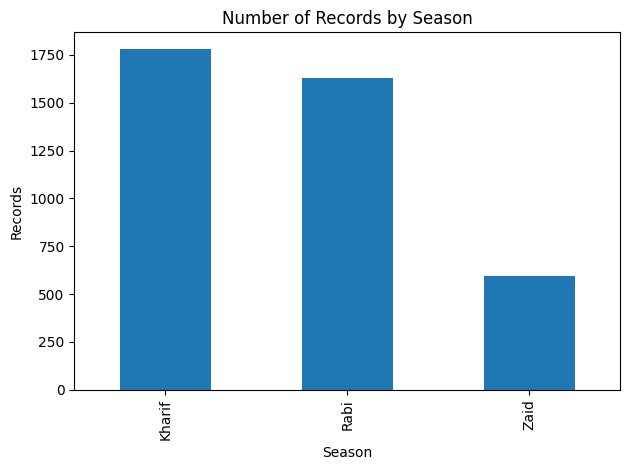

In [19]:
season_counts = clean_df["Season"].value_counts().sort_index()
ax = season_counts.plot(kind="bar")
ax.set_title("Number of Records by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Records")
plt.tight_layout()
plt.show()


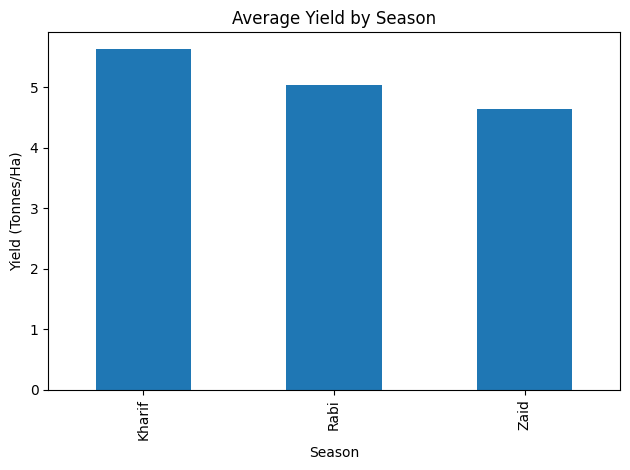

In [20]:
avg_yield = clean_df.groupby("Season")["Yield_Tonnes_Ha"].mean()
ax = avg_yield.plot(kind="bar")
ax.set_title("Average Yield by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


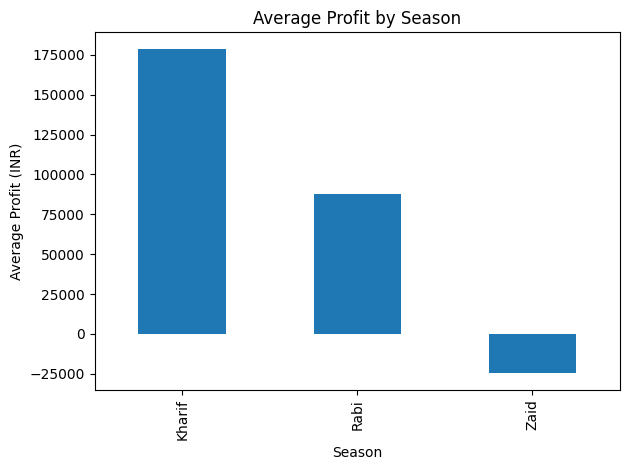

In [21]:
avg_profit = clean_df.groupby("Season")["Profit_INR"].mean()
ax = avg_profit.plot(kind="bar")
ax.set_title("Average Profit by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()


## 5. Discover relationships and variations within the dataset.

In [22]:
environment_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct"
]

season_environment = clean_df.groupby("Season")[environment_cols].mean().round(2)
display(season_environment)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


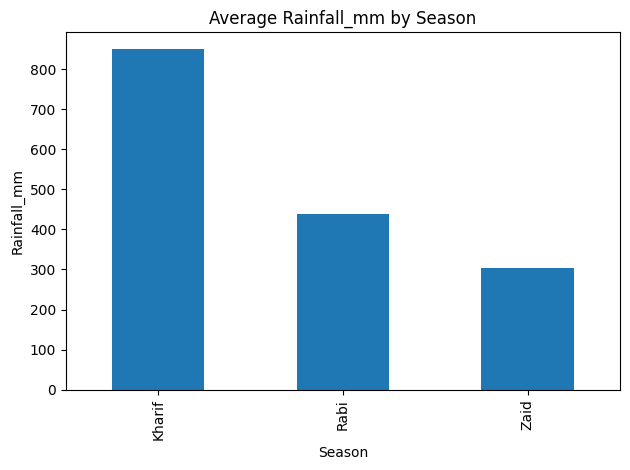

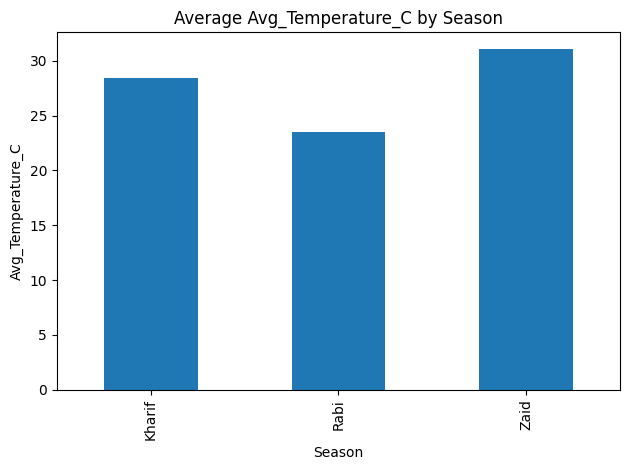

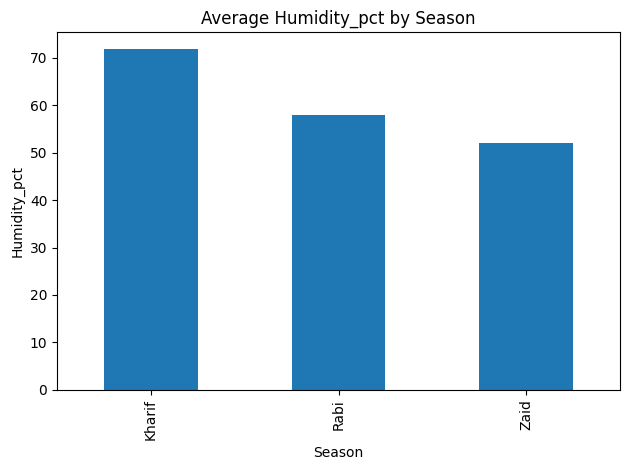

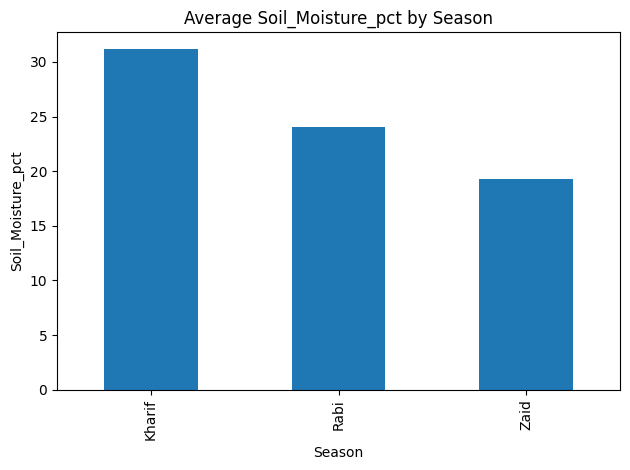

In [23]:
for col in ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct"]:
    values = clean_df.groupby("Season")[col].mean()
    ax = values.plot(kind="bar")
    ax.set_title(f"Average {col} by Season")
    ax.set_xlabel("Season")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()


## 6. Select suitable analytical and visualization techniques independently

In [24]:
resource_cols = [
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Water_Used_m3"
]

resource_summary = clean_df.groupby("Season")[resource_cols].mean().round(2)
display(resource_summary)


,Fertilizer_kg_ha,Pesticide_Litre_ha,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Water_Used_m3
Season,,,,,,
Kharif,187.08,5.08,120.02,58.10,105.30,"6,102.20"
Rabi,185.41,5.02,120.40,57.31,103.93,"5,846.99"
Zaid,184.64,5.17,120.53,58.13,105.42,"6,419.89"


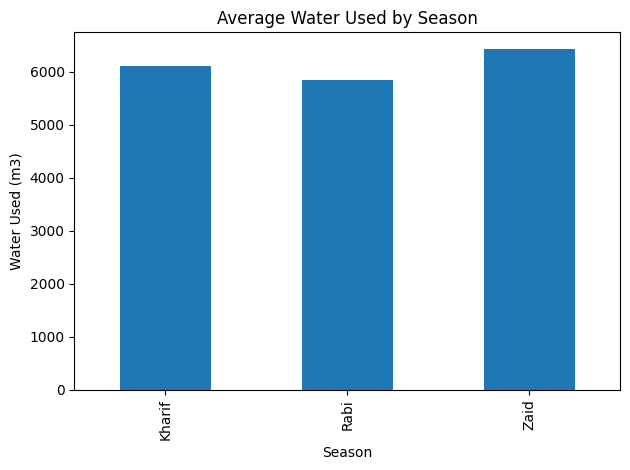

In [25]:
water = clean_df.groupby("Season")["Water_Used_m3"].mean()
ax = water.plot(kind="bar")
ax.set_title("Average Water Used by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Water Used (m3)")
plt.tight_layout()
plt.show()


## 7. Irrigation Method Analysis

In [26]:
irrigation_summary = clean_df.groupby(
    ["Season", "Irrigation_Method"]
).agg(
    Records=("Farm_ID", "size"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

display(irrigation_summary)


Records  Avg_Yield  Avg_Profit  Avg_Water_Used  \
Season Irrigation_Method                                                   
Kharif Drip                   405       7.26  317,222.07        5,953.37   
       Flood                  590       4.98  133,373.83        8,229.27   
       Rainfed                463       5.70  158,974.13        3,687.52   
       Sprinkler              321       4.66  116,880.49        5,863.27   
Rabi   Drip                   370       6.11  187,843.22        5,911.41   
       Flood                  526       5.06   58,824.80        7,766.83   
       Rainfed                438       3.93   45,232.48        3,298.29   
       Sprinkler              293       5.31   76,502.07        6,129.09   
Zaid   Drip                   140       5.85   21,291.84        5,837.99   
       Flood                  194       3.98  -69,786.78        8,113.69   
       Rainfed                140       3.06  -79,467.26        3,879.39   
       Sprinkler              120       6.14   57,909.40        7,324.41   

                          Avg_Water_Efficiency  
Season Irrigation_Method                        
Kharif Drip                               6.80  
       Flood                              3.64  
       Rainfed                            8.85  
       Sprinkler                          4.62  
Rabi   Drip                               6.05  
       Flood                              3.48  
       Rainfed                            6.87  
       Sprinkler                          4.64  
Zaid   Drip                               5.30  
       Flood                              2.73  
       Rainfed                            5.48  
       Sprinkler                          4.86

## 8. Environmental Conditions vs Agricultural Outcomes

In [27]:
environment_vs_outcome = clean_df[
    [        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day",
        "Soil_Moisture_pct",
        "Yield_Tonnes_Ha",
        "Production_Tonnes",
        "Profit_INR"
    ]
].corr().round(3)

display(environment_vs_outcome)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Rainfall_mm,1.00,0.20,0.52,-0.36,0.51,0.03,0.02,0.11
Avg_Temperature_C,0.20,1.00,0.14,-0.03,0.08,0.01,0.01,0.01
Humidity_pct,0.52,0.14,1.00,-0.30,0.45,0.01,0.00,0.06
Sunlight_Hours_Day,-0.36,-0.03,-0.30,1.00,-0.30,-0.01,-0.02,-0.06
Soil_Moisture_pct,0.51,0.08,0.45,-0.30,1.00,0.01,0.01,0.09
Yield_Tonnes_Ha,0.03,0.01,0.01,-0.01,0.01,1.00,0.88,0.49
Production_Tonnes,0.02,0.01,0.00,-0.02,0.01,0.88,1.00,0.55
Profit_INR,0.11,0.01,0.06,-0.06,0.09,0.49,0.55,1.00


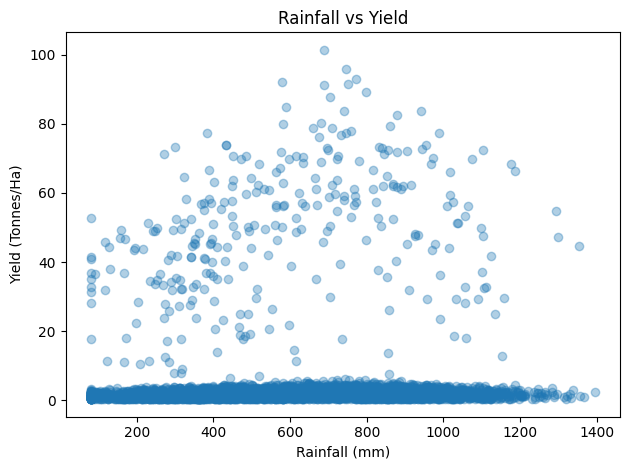

In [28]:
x = clean_df["Rainfall_mm"]
y = clean_df["Yield_Tonnes_Ha"]

plt.scatter(x, y, alpha=0.35)
plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


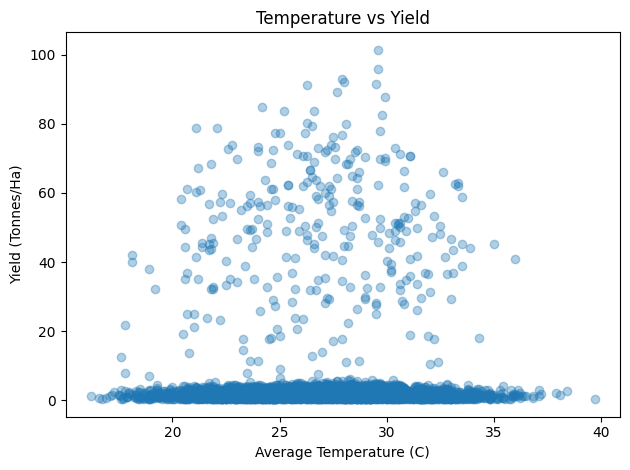

In [29]:
x = clean_df["Avg_Temperature_C"]
y = clean_df["Yield_Tonnes_Ha"]

plt.scatter(x, y, alpha=0.35)
plt.title("Temperature vs Yield")
plt.xlabel("Average Temperature (C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()


## 9. Economic Outcomes Across Seasons

In [30]:
economic_summary = clean_df.groupby("Season").agg(
    Farms=("Farm_ID", "size"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Median_Profit=("Profit_INR", "median"),
    Profitable_Farms_Pct=("Profit_INR", lambda s: (s > 0).mean() * 100),
    Loss_Making_Farms_Pct=("Profit_INR", lambda s: (s < 0).mean() * 100)
).round(2)

display(economic_summary)


,Farms,Avg_Cost,Avg_Revenue,Avg_Profit,Median_Profit,Profitable_Farms_Pct,Loss_Making_Farms_Pct
Season,,,,,,,
Kharif,1779,"531,804.41","710,719.06","178,914.65","38,808.00",57.79,42.21
Rabi,1627,"513,836.58","601,526.05","87,689.47","-3,187.00",48.86,51.14
Zaid,594,"543,976.73","519,171.90","-24,804.82","-62,144.00",35.52,64.48


## 10. Crop-wise Seasonal Performance

In [31]:
crop_season = clean_df.groupby(["Season", "Crop"]).agg(
    Records=("Farm_ID", "size"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

display(crop_season)


Records  Avg_Yield  Avg_Production   Avg_Profit  \
Season Crop                                                         
Kharif Chilli         185       1.73           14.46   954,380.42   
       Cotton         215       1.37           10.41   216,999.55   
       Groundnut      193       1.48           10.49   108,265.44   
       Maize          234       2.97           23.35   -39,332.67   
       Pulses         221       1.04            8.29    43,338.90   
       Rice           314       2.70           22.45   -64,903.40   
       Sugarcane      125      53.46          446.07 1,000,790.81   
       Wheat          292       2.25           18.31  -105,871.87   
Rabi   Chilli         163       1.47           10.97   638,572.50   
       Cotton         201       1.20            9.44   107,343.59   
       Groundnut      177       1.23            9.06    10,416.54   
       Maize          233       2.60           21.59   -89,133.40   
       Pulses         213       0.88            7.20   -14,309.14   
       Rice           274       2.32           17.22   -98,427.87   
       Sugarcane      129      43.29          365.26   731,612.86   
       Wheat          237       2.06           16.07  -119,954.57   
Zaid   Chilli          64       1.20            9.98   448,659.09   
       Cotton          92       0.96            6.93   -53,925.34   
       Groundnut       54       1.04            8.62   -68,872.50   
       Maize           84       2.29           17.94  -194,049.17   
       Pulses          62       0.67            4.94  -139,227.81   
       Rice           102       1.90           15.11  -227,239.34   
       Sugarcane       51      38.42          329.56   583,635.80   
       Wheat           85       1.75           14.06  -193,208.95   

                  Avg_Water_Efficiency  
Season Crop                             
Kharif Chilli                     3.26  
       Cotton                     2.13  
       Groundnut                  3.58  
       Maize                      6.05  
       Pulses                     3.35  
       Rice                       2.17  
       Sugarcane                 36.00  
       Wheat                      4.76  
Rabi   Chilli                     2.89  
       Cotton                     1.94  
       Groundnut                  2.90  
       Maize                      5.46  
       Pulses                     2.70  
       Rice                       1.84  
       Sugarcane                 27.92  
       Wheat                      4.69  
Zaid   Chilli                     2.20  
       Cotton                     1.49  
       Groundnut                  2.47  
       Maize                      4.75  
       Pulses                     1.95  
       Rice                       1.53  
       Sugarcane                 23.39  
       Wheat                      4.02

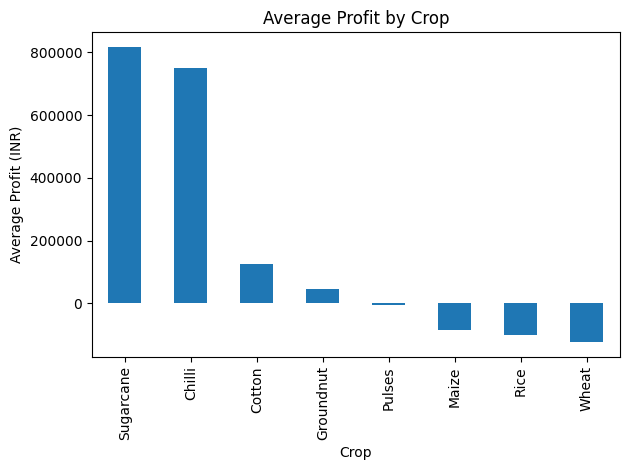

In [32]:
crop_profit = clean_df.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False)
ax = crop_profit.plot(kind="bar")
ax.set_title("Average Profit by Crop")
ax.set_xlabel("Crop")
ax.set_ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()


## 11. Are Seasonal Patterns Consistent Across States?

In [33]:
state_season = clean_df.groupby(["State", "Season"]).agg(
    Records=("Farm_ID", "size"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).reset_index().round(2)

display(state_season)

best_profit_season_by_state = state_season.loc[
    state_season.groupby("State")["Avg_Profit"].idxmax(),
    ["State", "Season", "Avg_Profit"]
].sort_values("State")

print("Best season by average profit in each state:")
display(best_profit_season_by_state)


,State,Season,Records,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
0,Andhra Pradesh,Kharif,240,5.68,"169,315.52",6.12
1,Andhra Pradesh,Rabi,204,3.47,"26,315.71",4.16
2,Andhra Pradesh,Zaid,85,4.45,"-84,084.87",4.07
3,Gujarat,Kharif,221,6.34,"217,051.33",6.38
4,Gujarat,Rabi,200,5.44,"82,846.20",5.18
5,Gujarat,Zaid,67,4.07,"-106,929.61",4.10
6,Karnataka,Kharif,209,6.46,"201,226.21",5.89
7,Karnataka,Rabi,206,4.57,"70,952.61",5.33
8,Karnataka,Zaid,74,6.62,"23,310.91",5.30
9,Madhya Pradesh,Kharif,226,5.99,"134,242.40",6.22


Best season by average profit in each state:


,State,Season,Avg_Profit
0,Andhra Pradesh,Kharif,"169,315.52"
3,Gujarat,Kharif,"217,051.33"
6,Karnataka,Kharif,"201,226.21"
9,Madhya Pradesh,Kharif,"134,242.40"
12,Maharashtra,Kharif,"168,801.05"
16,Punjab,Rabi,"169,294.52"
18,Tamil Nadu,Kharif,"211,303.96"
21,Telangana,Kharif,"199,668.38"


## 12. Correlation Analysis

In [34]:
corr = clean_df.select_dtypes(include=np.number).corr()

print("Strongest correlations with Yield:")
display(corr["Yield_Tonnes_Ha"].sort_values(ascending=False).head(12).round(3))

print("\nStrongest correlations with Profit:")
display(corr["Profit_INR"].sort_values(ascending=False).head(12).round(3))


Strongest correlations with Yield:


,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03



Strongest correlations with Profit:


,Profit_INR
Profit_INR,1.00
Revenue_INR,0.89
Production_Tonnes,0.55
Water_Efficiency_t_per_1000m3,0.49
Yield_Tonnes_Ha,0.49
Market_Price_INR_Tonne,0.23
Water_Used_m3,0.19
Farm_Area_Hectares,0.12
Rainfall_mm,0.11
Soil_Moisture_pct,0.09


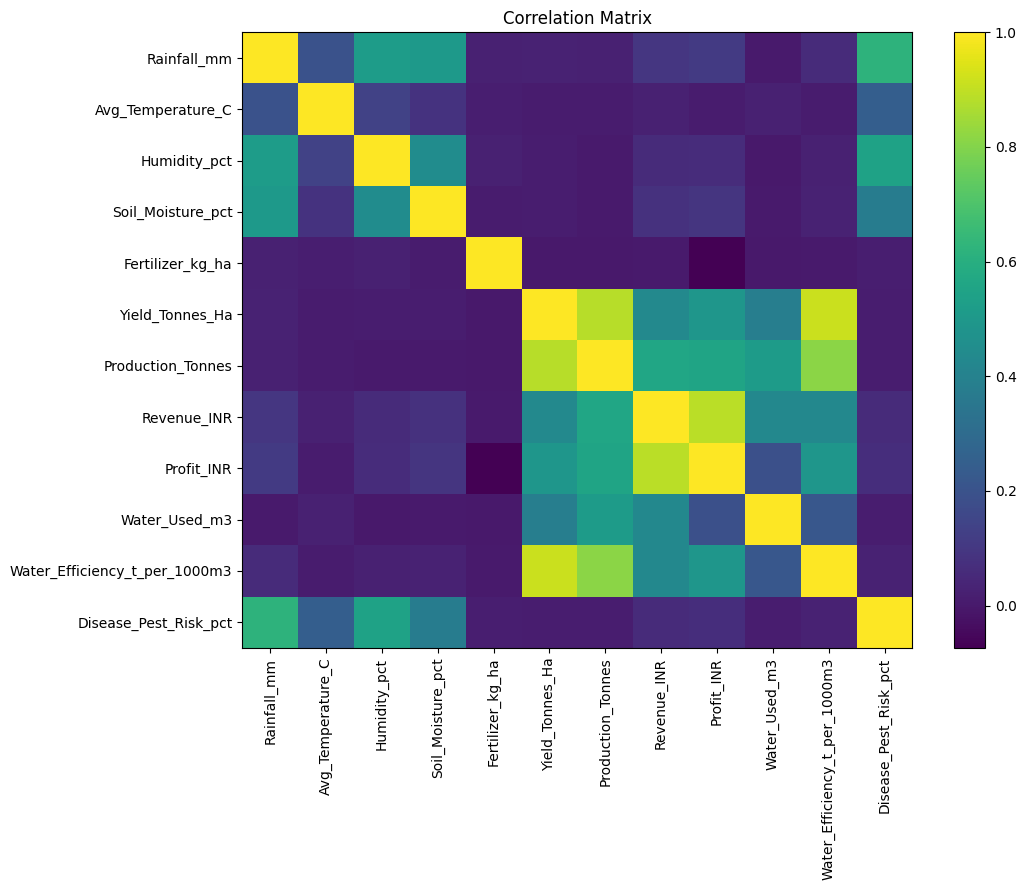

In [35]:
# Matplotlib-only correlation heatmap
selected = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

corr_matrix = clean_df[selected].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, aspect="auto")
ax.set_xticks(range(len(selected)))
ax.set_xticklabels(selected, rotation=90)
ax.set_yticks(range(len(selected)))
ax.set_yticklabels(selected)
fig.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 13. Identify Unusual or Unexpected Patterns

In [36]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()
    return pd.Series({
        "Q1": q1,
        "Q3": q3,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outliers": count
    })

outlier_cols = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

outlier_summary = pd.DataFrame({
    col: iqr_outlier_count(clean_df[col]) for col in outlier_cols
}).T.round(2)

display(outlier_summary)


,Q1,Q3,Lower_Bound,Upper_Bound,Outliers
Yield_Tonnes_Ha,1.05,2.83,-1.62,5.50,302.00
Production_Tonnes,5.02,24.36,-23.98,53.36,333.00
Profit_INR,"-148,731.75","216,187.75","-696,111.00","763,567.00",404.00
Water_Used_m3,"2,268.75","7,829.75","-6,072.75","16,171.25",276.00
Water_Efficiency_t_per_1000m3,1.66,5.15,-3.57,10.38,322.00


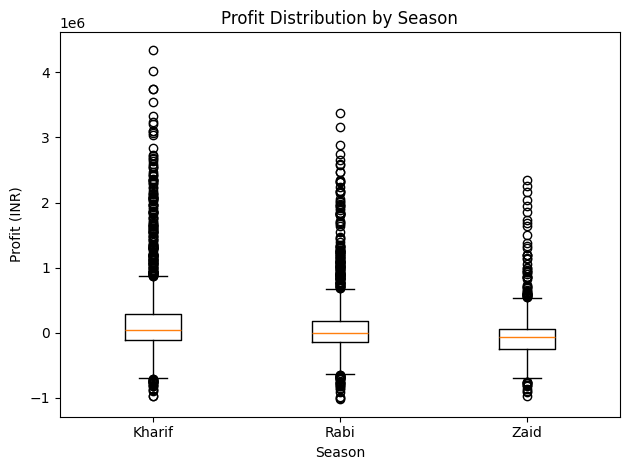

In [37]:
plt.boxplot([
    clean_df.loc[clean_df["Season"] == "Kharif", "Profit_INR"],
    clean_df.loc[clean_df["Season"] == "Rabi", "Profit_INR"],
    clean_df.loc[clean_df["Season"] == "Zaid", "Profit_INR"]
], tick_labels=["Kharif", "Rabi", "Zaid"])

plt.title("Profit Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


## 14. Statistical Testing of Seasonal Differences

In [38]:
from scipy.stats import f_oneway

test_metrics = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Disease_Pest_Risk_pct"
]

results = []

for metric in test_metrics:
    groups = [
        clean_df.loc[clean_df["Season"] == season, metric].dropna()
        for season in ["Kharif", "Rabi", "Zaid"]
    ]
    f_stat, p_value = f_oneway(*groups)
    results.append({
        "Metric": metric,
        "F_statistic": f_stat,
        "p_value": p_value,
        "Significant_at_0.05": p_value < 0.05
    })

anova_results = pd.DataFrame(results)
display(anova_results)


,Metric,F_statistic,p_value,Significant_at_0.05
0,Yield_Tonnes_Ha,1.54,0.21,False
1,Production_Tonnes,1.03,0.36,False
2,Profit_INR,34.29,0.00,True
3,Water_Used_m3,2.47,0.09,False
4,Water_Efficiency_t_per_1000m3,6.95,0.00,True
5,Rainfall_mm,"3,289.82",0.00,True
6,Avg_Temperature_C,"2,678.74",0.00,True
7,Humidity_pct,"1,574.77",0.00,True
8,Soil_Moisture_pct,"1,590.19",0.00,True
9,Disease_Pest_Risk_pct,"1,049.47",0.00,True


### Interpretation rule

- **p < 0.05**: there is statistical evidence that at least one seasonal mean differs.
- **p >= 0.05**: the available data does not provide enough evidence of a difference in the mean across seasons.

ANOVA indicates association/difference in this dataset; it does not prove causation.


## 15. Final Findings from This Dataset

In [39]:
season_final = clean_df.groupby("Season").agg(
    Records=("Farm_ID", "size"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Median_Yield=("Yield_Tonnes_Ha", "median"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Median_Profit=("Profit_INR", "median"),
    Profit_Rate_Pct=("Profit_INR", lambda s: (s > 0).mean() * 100),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

display(season_final)


,Records,Avg_Yield,Median_Yield,Avg_Production,Avg_Revenue,Avg_Cost,Avg_Profit,Median_Profit,Profit_Rate_Pct,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Season,,,,,,,,,,,,
Kharif,1779,5.63,1.94,46.31,"710,719.06","531,804.41","178,914.65","38,808.00",57.79,"6,102.20",5.89,54.47
Rabi,1627,5.04,1.67,41.49,"601,526.05","513,836.58","87,689.47","-3,187.00",48.86,"5,846.99",5.19,40.48
Zaid,594,4.64,1.46,38.89,"519,171.90","543,976.73","-24,804.82","-62,144.00",35.52,"6,419.89",4.41,38.22


## 16. Evidence-Based Conclusions

Using this dataset:

- **Kharif** has the highest average yield, production, revenue, profit, and water efficiency.
- **Rabi** is intermediate on most economic indicators.
- **Zaid** has the lowest average yield and production and shows a negative average profit.
- Kharif also has the highest average rainfall, humidity, soil moisture, and disease/pest risk.
- Zaid has the highest average temperature and the lowest rainfall and soil moisture.
- A larger percentage of Kharif records are profitable than Rabi or Zaid.
- Water efficiency is strongly associated with yield in this dataset.
- Seasonal environmental variables differ strongly across Kharif, Rabi, and Zaid.
- Average yield differences should be interpreted carefully because crops have very different yield scales (especially sugarcane), and crop composition can affect overall seasonal averages.
- State-level results are not perfectly identical: the best season can vary by state and metric.

These findings are descriptive/associational and should not be presented as causal proof.
